# Regularisation: Ridge, LASSO, and Elastic Net

## Overview

Regularisation adds a penalty to the loss function to shrink coefficients toward zero, reducing overfitting when p is large relative to n or when predictors are collinear.

| Method | Penalty | Effect | Best for |
|---|---|---|---|
| Ridge (L2) | sum(beta^2) | Shrinks all coefficients; never zeros | Many small effects, collinear predictors |
| LASSO (L1) | sum(|beta|) | Shrinks some to exactly zero (feature selection) | Sparse true models |
| Elastic Net | alpha*L1 + (1-alpha)*L2 | Combines both | Correlated predictors + sparsity |

The penalty strength `alpha` (sklearn) is a hyperparameter selected by cross-validation.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

rng = np.random.default_rng(42)
n, p = 150, 20
# 5 true predictors, 15 noise
X = rng.normal(0, 1, (n, p))
true_coef = np.zeros(p)
true_coef[:5] = [3.0, -2.0, 1.5, -1.0, 0.8]
y = X @ true_coef + rng.normal(0, 2, n)
feature_names = [f"x{i:02d}" for i in range(p)]
print(f"True non-zero coefficients: {dict(zip(feature_names[:5], true_coef[:5]))}")

True non-zero coefficients: {'x00': np.float64(3.0), 'x01': np.float64(-2.0), 'x02': np.float64(1.5), 'x03': np.float64(-1.0), 'x04': np.float64(0.8)}


---
## Standardisation and Train/Test Split

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Always fit scaler on training data only, then transform both sets.")

Train: (112, 20), Test: (38, 20)
Always fit scaler on training data only, then transform both sets.


---
## Ridge and LASSO with CV-selected alpha

In [3]:
# RidgeCV and LassoCV select alpha via cross-validation internally
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5).fit(X_tr_sc, y_train)
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42).fit(X_tr_sc, y_train)
print(f"Ridge best alpha: {ridge_cv.alpha_:.4f}")
print(f"LASSO best alpha: {lasso_cv.alpha_:.4f}")
print(f"LASSO non-zero coefficients: {(lasso_cv.coef_ != 0).sum()} / {p}")
# Test performance
for name, m in [("Ridge", ridge_cv),("LASSO", lasso_cv)]:
    y_pred = m.predict(X_te_sc)
    print(f"{name}: test RMSE={np.sqrt(mean_squared_error(y_test,y_pred)):.3f}, R2={r2_score(y_test,y_pred):.3f}")

Ridge best alpha: 8.6975
LASSO best alpha: 0.1520
LASSO non-zero coefficients: 8 / 20
Ridge: test RMSE=2.111, R2=0.776
LASSO: test RMSE=2.052, R2=0.788


---
## Coefficient Paths

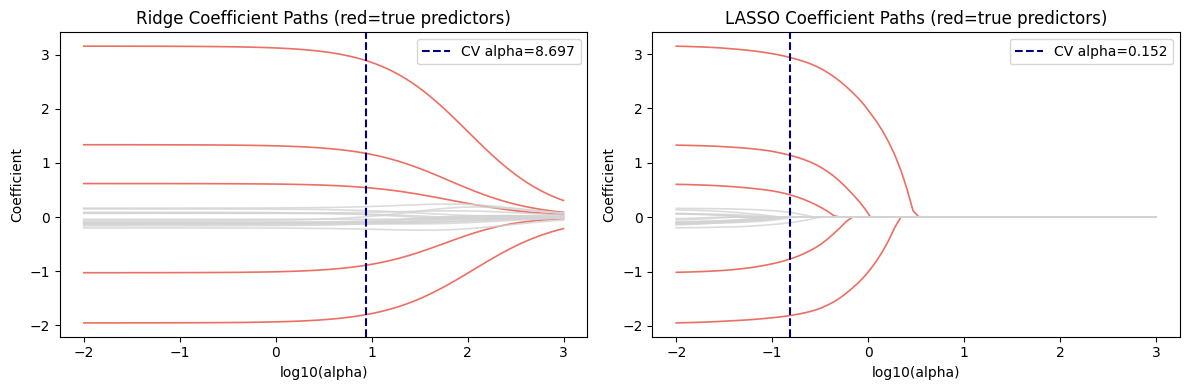

In [4]:
alphas_path = np.logspace(-2, 3, 80)
ridge_coefs = [Ridge(alpha=a).fit(X_tr_sc, y_train).coef_ for a in alphas_path]
lasso_coefs = [Lasso(alpha=a, max_iter=10000).fit(X_tr_sc, y_train).coef_ for a in alphas_path]
fig, axes = plt.subplots(1,2,figsize=(12,4))
for ax, coefs, name, best_a in zip(
    axes, [ridge_coefs,lasso_coefs], ["Ridge","LASSO"],
    [ridge_cv.alpha_, lasso_cv.alpha_]):
    for i, c in enumerate(np.array(coefs).T):
        ax.plot(np.log10(alphas_path), c, lw=1.2,
                color="#e74c3c" if i<5 else "lightgrey", alpha=0.8)
    ax.axvline(np.log10(best_a), color="navy", lw=1.5, linestyle="--", label=f"CV alpha={best_a:.3f}")
    ax.set_xlabel("log10(alpha)"); ax.set_ylabel("Coefficient")
    ax.set_title(f"{name} Coefficient Paths (red=true predictors)")
    ax.legend()
plt.tight_layout(); plt.show()

---
## Comparing Coefficient Recovery

     true  ridge  lasso
x00   3.0  2.896  2.938
x01  -2.0 -1.807 -1.811
x02   1.5  1.177  1.140
x03  -1.0 -0.893 -0.773
x04   0.8  0.545  0.413
x05   0.0 -0.074 -0.000
x06   0.0  0.118  0.000
x07   0.0 -0.107 -0.000
x08   0.0 -0.092 -0.000
x09   0.0 -0.042 -0.000
x10   0.0  0.192  0.089
x11   0.0  0.086  0.000
x12   0.0  0.005 -0.000
x13   0.0  0.052  0.000
x14   0.0 -0.125 -0.000
x15   0.0  0.046  0.000
x16   0.0 -0.093 -0.009
x17   0.0 -0.224 -0.103
x18   0.0 -0.123 -0.000
x19   0.0 -0.125 -0.000


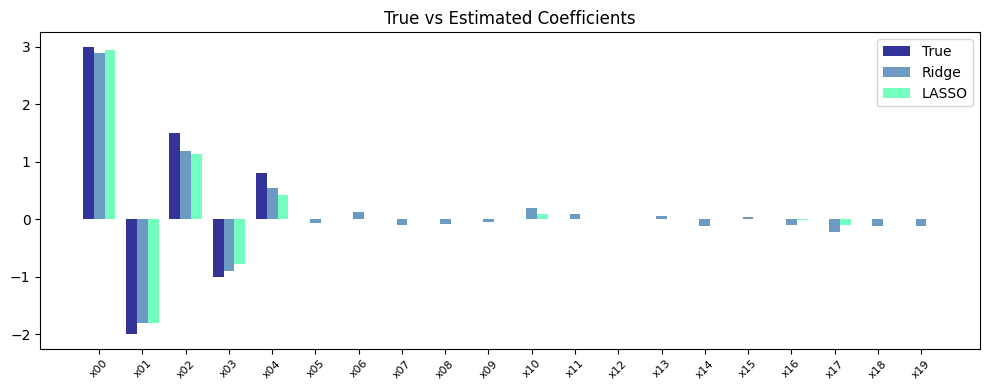

In [5]:
results = pd.DataFrame({
    "true":    true_coef,
    "ridge":   ridge_cv.coef_,
    "lasso":   lasso_cv.coef_
}, index=feature_names)
print(results.round(3))
fig, ax = plt.subplots(figsize=(10,4))
x_pos = np.arange(p)
w = 0.25
ax.bar(x_pos-w, results["true"],  w, label="True",  color="navy",     alpha=0.8)
ax.bar(x_pos,   results["ridge"], w, label="Ridge", color="steelblue", alpha=0.8)
ax.bar(x_pos+w, results["lasso"], w, label="LASSO", color="#4fffb0",   alpha=0.8)
ax.set_xticks(x_pos); ax.set_xticklabels(feature_names, rotation=45, fontsize=8)
ax.legend(); ax.set_title("True vs Estimated Coefficients")
plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Not standardising predictors before regularisation**  
Ridge and LASSO penalise the magnitude of coefficients. If predictors are on different scales, the penalty applies unequally. Always standardise to zero mean and unit variance before fitting regularised models.

**2. Fitting the scaler on the full dataset before the train/test split**  
Fitting `StandardScaler` on all data before splitting leaks test set information into the scaler. Always fit on training data only and apply `transform` (not `fit_transform`) to the test set.

**3. Using LASSO when predictors are highly correlated**  
LASSO tends to select one predictor from a correlated group arbitrarily and zero out the rest. This makes coefficient interpretation unstable. Use Elastic Net or Ridge when predictors are correlated.

**4. Treating the LASSO zero coefficients as confirmed irrelevant predictors**  
LASSO performs selection but the selected set is unstable — run on a different subsample it may select a different set. Use stability selection or bootstrap-based approaches before drawing hard conclusions about which variables matter.

**5. Selecting alpha on the test set**  
Tuning alpha by evaluating on the test set and picking the best alpha overfits to the test set. Always select alpha via cross-validation on training data only, then evaluate once on the held-out test set.

---
*python_methods_library - Samantha McGarrigle*